# Customer Geography Analysis: Why is West different?

**The puzzle:** East holds 47% of customers, West only 16%, and West's revenue gap is even worse. Demographic dimensions (age, channel) are flat across regions. So *what* is different about West?

**The answer (spoiler):** It's not who the customers are. It's *what they buy*. West shoppers prefer Outdoor; East shoppers prefer Streetwear. The two product lines have very different price points, and the catalog has a structural hole that under-serves the Outdoor-loving West market.

This notebook walks through the diagnosis in 4 charts.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA = "data"
PLOT_SIZE = (10, 5)
REGION_ORDER = ["East", "Central", "West"]
REGION_COLORS = {"East": "tab:blue", "Central": "tab:orange", "West": "tab:green"}

# --- Load ---
customers = pd.read_csv(f"{DATA}/customers.csv", parse_dates=["signup_date"])
geography = pd.read_csv(f"{DATA}/geography.csv")
orders    = pd.read_csv(f"{DATA}/orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(f"{DATA}/order_items.csv")
products  = pd.read_csv(f"{DATA}/products.csv")

# --- Join: customers + region ---
cust_geo = customers.drop(columns=["city"]).merge(geography, on="zip", how="left")

# --- Join: order_items + orders + region + products (the workhorse table) ---
order_items["gross"] = order_items["quantity"] * order_items["unit_price"]
order_items["discount"] = order_items["discount_amount"].fillna(0)
order_items["net"] = order_items["gross"] - order_items["discount"]
order_items["has_promo"] = order_items["promo_id"].notna()

oi_full = (
    order_items
    .merge(orders[["order_id", "zip", "order_date"]], on="order_id")
    .merge(geography[["zip", "region"]], on="zip", how="left")
    .merge(products[["product_id", "category", "segment", "price"]], on="product_id", how="left")
    .dropna(subset=["region"])
)

print(f"Customers:      {len(cust_geo):,}")
print(f"Orders:         {oi_full['order_id'].nunique():,}")
print(f"Order line items: {len(oi_full):,}")
print(f"Regions:        {sorted(oi_full['region'].unique())}")

C:\Users\LEGION\AppData\Local\Temp\ipykernel_1856\4033906312.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(f"{DATA}/order_items.csv")


Customers:      121,930
Orders:         646,945
Order line items: 714,669
Regions:        ['Central', 'East', 'West']


## 1. The puzzle: three regions, three different sizes

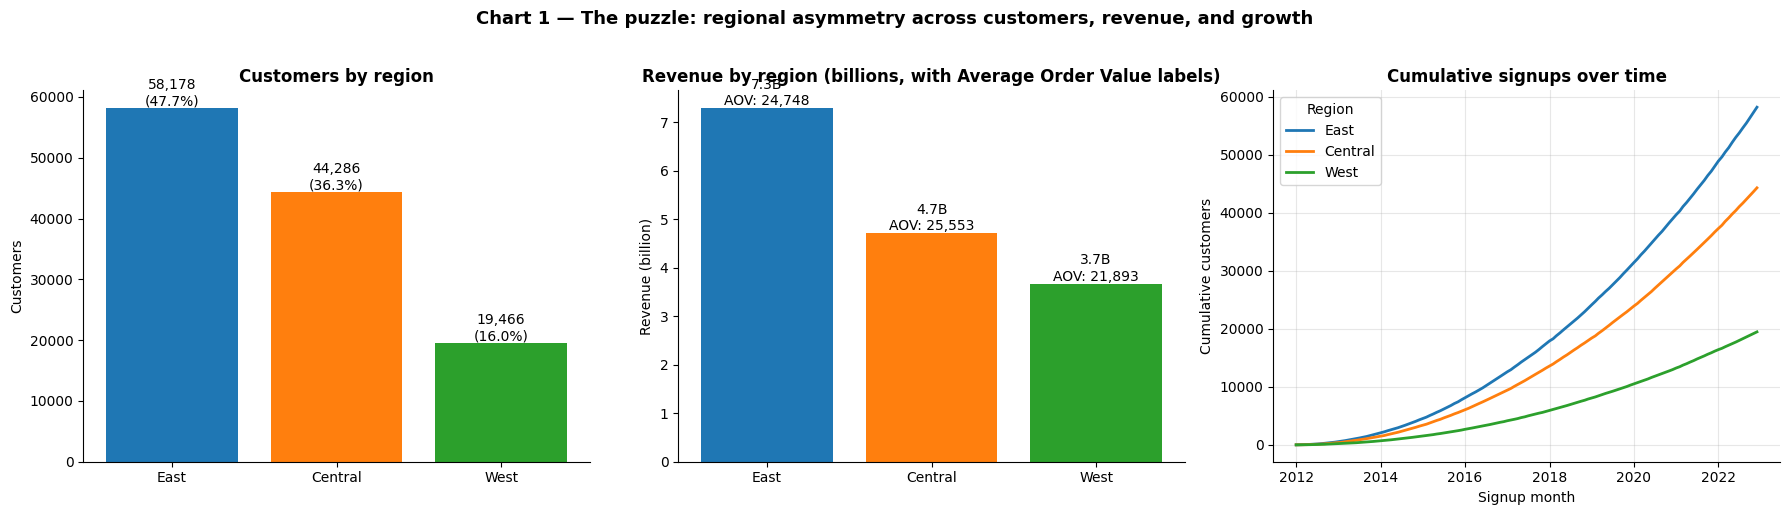

In [17]:
# Three-panel: customers by region, revenue by region, cumulative signups
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: customer counts ---
cust_by_region = cust_geo["region"].value_counts().reindex(REGION_ORDER)
colors = [REGION_COLORS[r] for r in cust_by_region.index]
bars = axes[0].bar(cust_by_region.index, cust_by_region.values, color=colors)
axes[0].set_title("Customers by region", weight="bold")
axes[0].set_ylabel("Customers")
axes[0].ticklabel_format(style="plain", axis="y")
total = cust_by_region.sum()
for bar, v in zip(bars, cust_by_region.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v, f"{v:,}\n({v/total:.1%})",
                 ha="center", va="bottom", fontsize=10)

# --- Panel B: revenue + AOV by region ---
rev_by_region = oi_full.groupby("region").agg(
    orders=("order_id", "nunique"),
    revenue=("net", "sum"),
).reindex(REGION_ORDER)
rev_by_region["aov"] = rev_by_region["revenue"] / rev_by_region["orders"]

colors = [REGION_COLORS[r] for r in rev_by_region.index]
bars = axes[1].bar(rev_by_region.index, rev_by_region["revenue"] / 1e9, color=colors)
axes[1].set_title("Revenue by region (billions, with Average Order Value labels)", weight="bold")
axes[1].set_ylabel("Revenue (billion)")
for bar, rev, aov in zip(bars, rev_by_region["revenue"], rev_by_region["aov"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, rev/1e9,
                 f"{rev/1e9:.1f}B\nAOV: {aov:,.0f}",
                 ha="center", va="bottom", fontsize=10)

# --- Panel C: cumulative signups over time ---
signups = (
    cust_geo.dropna(subset=["region"])
    .assign(month=cust_geo["signup_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "region"]).size().unstack(fill_value=0)
    .reindex(columns=REGION_ORDER)
    .sort_index()
    .cumsum()
)
for region in signups.columns:
    axes[2].plot(signups.index, signups[region], label=region,
                 color=REGION_COLORS[region], linewidth=2)
axes[2].set_title("Cumulative signups over time", weight="bold")
axes[2].set_ylabel("Cumulative customers")
axes[2].set_xlabel("Signup month")
axes[2].legend(title="Region")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Chart 1 — The puzzle: regional asymmetry across customers, revenue, and growth",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

**What the chart shows:**

- **East dominates customers** (47%) and revenue (~₫7.3B). **West has the smallest of everything** — 16% of customers and ~₫3.7B revenue.
- The AOV labels reveal the hidden second story: **East ₫24.7K, Central ₫25.5K, West only ₫21.9K**. West isn't just smaller — each West order is also ~14% smaller in value.
- The growth lines confirm it's structural: West's curve is shallower than East's. The gap is *widening*, not closing.

**Conclusion**: West underperforms on three dimensions at once. We have done checks showed customer demographics (age, channel mix) are essentially identical across regions, so it's not *who* the customers are. So we will investigate on where exactly does the Average Orders Value (AOV) gap live?

## 2. Where does the AOV gap come from?

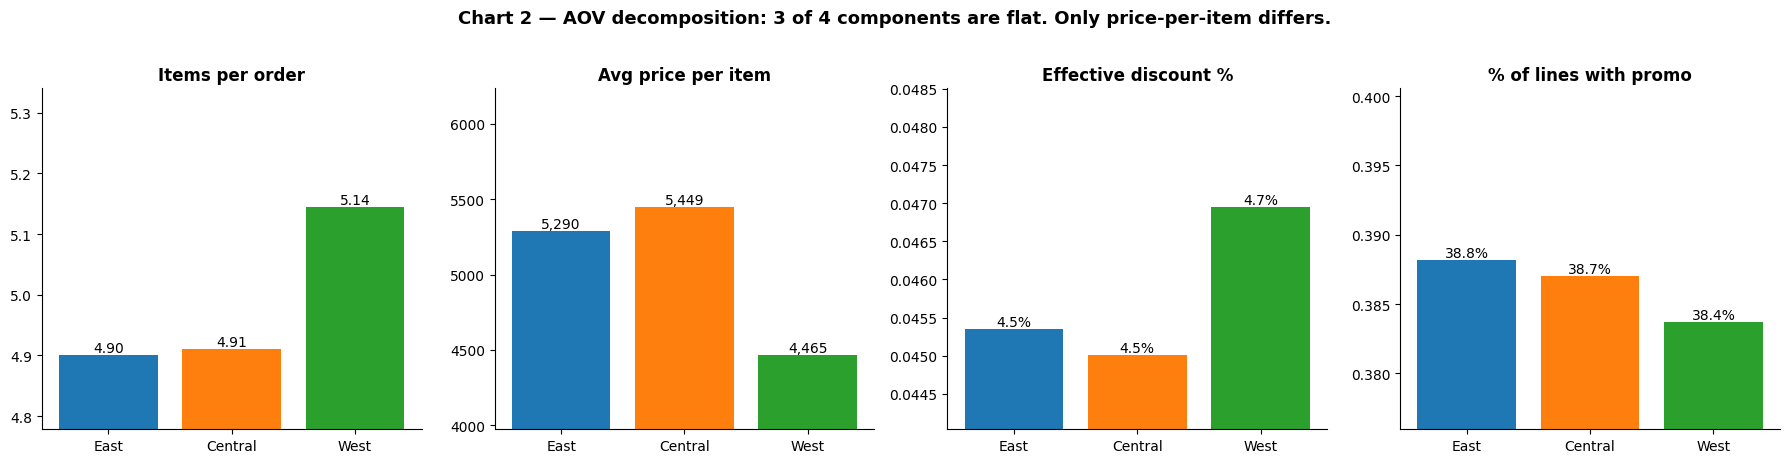

,orders,items_per_order,price_per_item,discount_rate,promo_share
region,,,,,
East,"294,612",4.90,"5,290.21",4.54%,38.81%
Central,"184,691",4.91,"5,448.82",4.50%,38.70%
West,"167,642",5.14,"4,465.15",4.70%,38.37%


In [14]:
# AOV = items_per_order × price_per_item × (1 - discount_rate)
# Decompose each component by region
decomp = (
    oi_full.groupby("region")
    .agg(
        orders=("order_id", "nunique"),
        items=("quantity", "sum"),
        gross=("gross", "sum"),
        discount=("discount", "sum"),
        promo_lines=("has_promo", "sum"),
        total_lines=("order_id", "size"),
    )
    .assign(
        items_per_order=lambda d: d["items"] / d["orders"],
        price_per_item=lambda d: d["gross"] / d["items"],
        discount_rate=lambda d: d["discount"] / d["gross"],
        promo_share=lambda d: d["promo_lines"] / d["total_lines"],
    )
    .reindex(REGION_ORDER)
)

metrics = [
    ("items_per_order", "Items per order",       "{:.2f}"),
    ("price_per_item",  "Avg price per item",    "{:,.0f}"),
    ("discount_rate",   "Effective discount %",  "{:.1%}"),
    ("promo_share",     "% of lines with promo", "{:.1%}"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (col, title, fmt) in zip(axes, metrics):
    vals = decomp[col].values
    colors = [REGION_COLORS[r] for r in decomp.index]
    bars = ax.bar(decomp.index, vals, color=colors)
    ax.set_title(title, weight="bold")
    # tight y-axis around the data so any real difference pops
    lo, hi = vals.min(), vals.max()
    pad = max((hi - lo) * 0.5, hi * 0.02)
    ax.set_ylim(max(0, lo - pad), hi + pad * 1.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Chart 2 — AOV decomposition: 3 of 4 components are flat. Only price-per-item differs.",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(decomp[["orders", "items_per_order", "price_per_item", "discount_rate", "promo_share"]]
        .style.format({
            "orders": "{:,.0f}",
            "items_per_order": "{:.2f}",
            "price_per_item": "{:,.2f}",
            "discount_rate": "{:.2%}",
            "promo_share": "{:.2%}",
        }))

**What the chart shows:**

- **Items per order, discount rate, and promo share are essentially identical** across all three regions (within 0.5 pp). West actually buys *slightly more* items per order (5.14 vs ~4.90).
- The only real gap is **price per item**: ₫5,449 in Central, ₫5,290 in East, but only ₫4,465 in West — about **18% lower**.
- That single component explains the entire 14% AOV gap.

**Conclusion**: West shoppers are not less engaged (their basket size is the highest). They're not getting deeper discounts either. They're just paying less per item. The next chart asks: are they paying less for the *same* products, or buying *different* products?

## 3. Same products at the same prices — but very different baskets

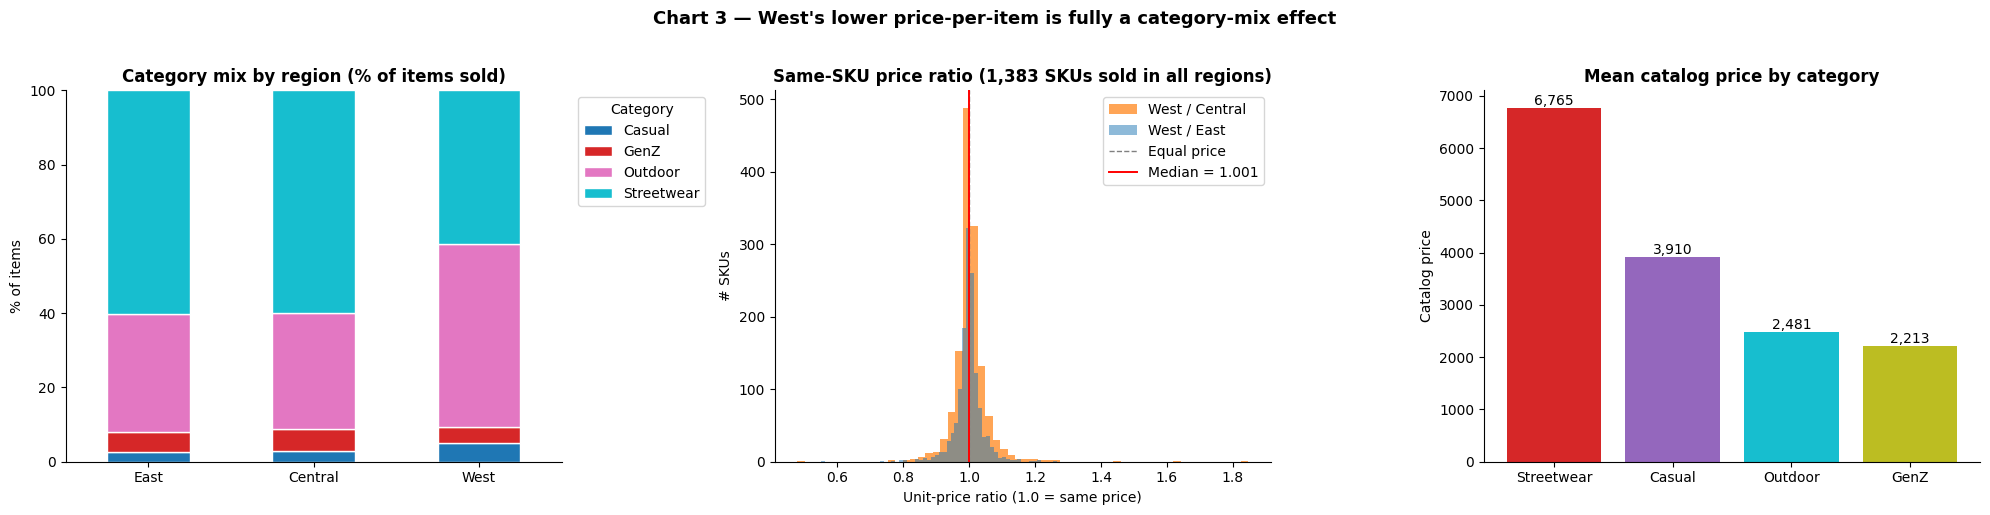

In [15]:
# Three-panel: category mix by region, same-SKU price ratio, mean catalog price by category

# --- Panel A: category mix by region ---
cat_mix = oi_full.groupby(["region", "category"])["quantity"].sum().unstack(fill_value=0)
cat_pct = cat_mix.div(cat_mix.sum(axis=1), axis=0).reindex(REGION_ORDER) * 100

# --- Panel B: same-SKU price ratio (West vs Central + East) ---
sku_price = (
    oi_full.groupby(["product_id", "region"])["unit_price"].mean()
           .unstack("region").dropna()
)
sku_price["W_vs_C"] = sku_price["West"] / sku_price["Central"]
sku_price["W_vs_E"] = sku_price["West"] / sku_price["East"]
median_W_C = sku_price["W_vs_C"].median()

# --- Panel C: mean catalog price by category ---
cat_price = products.groupby("category")["price"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel A
cat_pct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10", edgecolor="white")
axes[0].set_title("Category mix by region (% of items sold)", weight="bold")
axes[0].set_ylabel("% of items")
axes[0].set_xlabel("")
axes[0].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

# Panel B
axes[1].hist(sku_price["W_vs_C"], bins=60, color="tab:orange", alpha=0.7, label="West / Central")
axes[1].hist(sku_price["W_vs_E"], bins=60, color="tab:blue",   alpha=0.5, label="West / East")
axes[1].axvline(1.0, color="gray", linestyle="--", linewidth=1, label="Equal price")
axes[1].axvline(median_W_C, color="red", linestyle="-", linewidth=1.4,
                label=f"Median = {median_W_C:.3f}")
axes[1].set_title(f"Same-SKU price ratio ({len(sku_price):,} SKUs sold in all regions)", weight="bold")
axes[1].set_xlabel("Unit-price ratio (1.0 = same price)")
axes[1].set_ylabel("# SKUs")
axes[1].legend()

# Panel C
cat_colors = ["tab:red", "tab:purple", "tab:cyan", "tab:olive"][:len(cat_price)]
bars = axes[2].bar(cat_price.index, cat_price.values, color=cat_colors)
axes[2].set_title("Mean catalog price by category", weight="bold")
axes[2].set_ylabel("Catalog price")
axes[2].ticklabel_format(style="plain", axis="y")
for bar, v in zip(bars, cat_price.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
                 ha="center", va="bottom", fontsize=10)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Chart 3 — West's lower price-per-item is fully a category-mix effect",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

**What the chart shows:**

- **Panel A (mix):** East and Central baskets are 60% **Streetwear**. West's basket is only 41% Streetwear — replaced by **Outdoor** (49%, vs ~31% elsewhere).
- **Panel B (pricing):** for the 1,383 SKUs sold in all regions, the median West/Central unit-price ratio is **1.001** — essentially identical. **Pricing is fully ruled out**: same products cost the same everywhere.
- **Panel C (catalog):** Streetwear (East/Central's favorite) averages ₫6,765 per item. **Outdoor (West's favorite) averages only ₫2,481** — about 63% cheaper as a category.

**Mechanism locked in**: West's basket is tilted toward an intrinsically cheaper product line. Same prices, different products. This is not a discount problem, not a pricing problem, not an engagement problem — it's a product-mix preference.

## Conclusion

### Findings

1. **West has 16% of customers and 14% lower AOV** (₫21,893 vs ₫24,748 East, ₫25,553 Central).
2. **The AOV gap is entirely price-per-item** (West ₫4,465 vs Central ₫5,449, -18%). Items per order, discount rate, and promo share are flat across regions.
3. **Same SKUs cost the same everywhere** (median W/C ratio = 1.001 across 1,383 SKUs). It's not a pricing problem.
4. **It's a category-mix problem.** West is 49% Outdoor (avg ₫2,481/item); East is 60% Streetwear (avg ₫6,765/item).
5. **West is actually the most engaged region**, with 5.14 items/order vs 4.90 elsewhere.

### Suggestions

| # | Action | Confidence | Estimated impact |
|---|---|---|---|
| 1 | **Acquire more West customers** (16% → 25% share). Same demographics + same channels as East mean the same playbook works. | High | **+₫2.0–2.5B / yr** |
| 2 | **Outdoor bundles for West** (push items/order from 5.14 → 5.5, AOV ₫21,893 → ₫23,427). | Medium | **+₫260M / yr** |
| 3 | **Region-specific creative** (Outdoor-first storefront for West). Low cost, A/B testable. | Medium | Multiplies #1 by 5–15% |
